In [15]:
#Load muckrakers

import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from difflib import get_close_matches
import os
import pymongo
from pymongo import MongoClient

In [4]:
# Connect to MongoDB
client =  MongoClient('localhost', 27017)
db = client['final']
collection = db['my_df']

# Get the collection from MongoDB
cursor = collection.find()
data = list(cursor)

# Convert data to Pandas DataFrame
df = pd.DataFrame(data)

# Close MongoDB connection
client.close()


In [5]:
df

,_id,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,album_year,playlist_name,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,656fcc8880162b38b8b346d5,1iQDltZqI7BXnHrFy4Qo1k,Trampoline (with ZAYN),SHAED,90,5QqqBZmdQmY1MvlnpBkagB,Trampoline (with ZAYN),9/26/2019,2019,Pop - Pop UK - 2019 - Canadian Pop - 2019 - Pop,...,7,-5.782,0,0.0334,0.560000,0.000000,0.1370,0.498,126.803,184280.0
1,656fcc8880162b38b8b346d6,0u2P5u6lvoDfwTYjAADbn4,lovely (with Khalid),Billie Eilish,89,2sBB17RXTamvj7Ncps15AK,lovely (with Khalid),4/19/2018,2018,PROJECT: Contemporary,...,4,-10.109,0,0.0333,0.934000,0.000000,0.0950,0.120,115.284,200186.0
2,656fcc8880162b38b8b346d7,6kls8cSlUyHW2BUOkDJIZE,Hate Me (with Juice WRLD),Ellie Goulding,88,29FoTD5vBY3Fq1QWhbl3FM,Hate Me (with Juice WRLD),6/26/2019,2019,Intro to Post-Teen Pop,...,8,-4.628,1,0.0507,0.108000,0.000000,0.1440,0.759,75.025,186223.0
3,656fcc8880162b38b8b346d8,2qxmye6gAegTMjLKEBoR3d,Let Me Down Slowly,Alec Benjamin,86,6jKZplJpy21R5lHaYHHjmZ,Narrated For You,11/16/2018,2018,urban contemporary,...,1,-5.714,0,0.0318,0.740000,0.000000,0.1240,0.483,150.073,169354.0
4,656fcc8880162b38b8b346d9,6IRdLKIyS4p7XNiP8r6rsx,all the good girls go to hell,Billie Eilish,86,0S0KGZnfBGSIssfF54WSJh,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",3/29/2019,2019,Music&Other Drugs,...,8,-8.922,0,0.3720,0.283000,0.143000,0.1770,0.569,185.044,168840.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17972,656fcc8880162b38b8b38d09,5I9P0RYdL5AVATzHSW2Mjw,1 Ask,Ebhoni,0,6pwhTqDm7PL5K9XjYSEvpN,1 Ask,6/5/2017,2017,EDM Pop,...,0,-9.064,0,0.0603,0.023800,0.000000,0.0666,0.529,144.636,175621.0
17973,656fcc8880162b38b8b38d0a,2qIOlORAibicgvcVBv992k,Still Swingin',Papa Roach,0,4rUru08MiWf8LD2jynZeS8,The Connection,10/2/2012,2012,Locker Room,...,1,-6.312,1,0.0572,0.000126,0.000149,0.1380,0.679,139.006,203293.0
17974,656fcc8880162b38b8b38d0b,2kJsHQMFO7jj2qX3QjPKP1,Burial,Pusha T,0,2Q70RGvclVQDwq7zGa3ViZ,Burial,3/14/2014,2014,Locker Room,...,9,-5.215,1,0.0512,0.014800,0.003750,0.3470,0.410,146.011,224225.0
17975,656fcc8880162b38b8b38d0c,78CKs2sQgviSRHygJHrhEh,Blue Savannah,Erasure,0,7ciDU0UiqIyh4ZDjZEgdM3,Always - The Very Best of Erasure (Deluxe Vers...,10/30/2015,2015,Electropop 80/90s,...,2,-7.191,1,0.0279,0.045000,0.000398,0.1310,0.504,134.918,259800.0


In [6]:
print(df.columns.tolist())

['_id', 'track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


In [7]:
# Create a report of songs with associated data, 
# this is a building block of the search_song function.

def create_song_report():
    song_report =  df[['track_name','track_artist', 'track_popularity', 'album_year','playlist_genre','energy']].rename(columns={'track_name': 'Title', 'track_artist' : 'Artist',
                                                                                                                                     'track_popularity': 'Popularity','album_year' : 'Release Year',
                                                                                                                                     'playlist_genre' : 'Genre' ,'energy' : 'Energy'})
    song_report = pd.DataFrame(song_report, columns=['Title','Artist','Popularity','Release Year','Genre','Energy'])
    #artist_report = artist_report.set_index('Title')

    return song_report

In [8]:
song_report = create_song_report()

In [12]:
# Retrieve an approximate match of a given search parameter.
# this is a building block of the search_song function.

def retrieve_song_data(artist_reportsong_report, key_value, threshold=0.6):
 
    # Check if the 'Title' column exists in the DataFrame
    if 'Title' not in song_report.columns:
        print("Error: Title column not assigned in dataframe.")
        return None

    # Search for the key value in the 'Title' column
    matches = get_close_matches(key_value, song_report['Title'], n=1, cutoff=threshold)

    # Check if any matches were found
    if matches:
        # Get the first matching record as a Pandas Series
        result = song_report[song_report['Title'] == matches[0]].iloc[0]
        return result
    else:
        print(f"No record found with a similar value to {key_value} in 'Title' column.")
        return None


In [13]:
#Search function to provide an individual song that is in the dataframe. 

def search_song():
    title=input("Enter song title: ")
    title=str(title)
    result_record = retrieve_song_data(song_report, title)

    if result_record is not None:
        print("Closest match to title found:")
        print(result_record)

In [17]:
search_song()

Enter song title:  darling


Closest match to title found:
Title                 Darling
Artist          Nath Jennings
Popularity                 17
Release Year             2020
Genre                     edm
Energy                  0.648
Name: 13969, dtype: object


In [19]:
# Make a copy of the original table, and put it in a dataframe. 
    
track_data = pd.DataFrame(df, columns=['track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 
                                          'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id',
                                          'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 
                                          'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'])

In [20]:
#Create a histogram of one of the column variables. Takes in the column variable as an input, but needs to be spelled correctly.
# Maybe I should give them a list of the columns available? 
# Prints the histogram with labeling that reflects the input chosen.


def create_hist():
   
    var = input('Enter column name to analyze.')
    
    if var not in track_data.columns:
            print(f"Error: {var} not found in avilable DataFrame columns.")
            return None
# Check if the 'Title' column exists in the DataFrame
    if pd.api.types.is_numeric_dtype(track_data[var]):

        track_data[var].hist(bins = 75, color= '#92cf51', edgecolor = 'black')
        plt.xlabel(f"Measure of {var}.")
        plt.ylabel('Count of Tracks')
        plt.title(f"Analysis of {var}.")
        
    else:
        print(f"Error: {var} does not contain numeric data.")

Enter column name to analyze. danceability


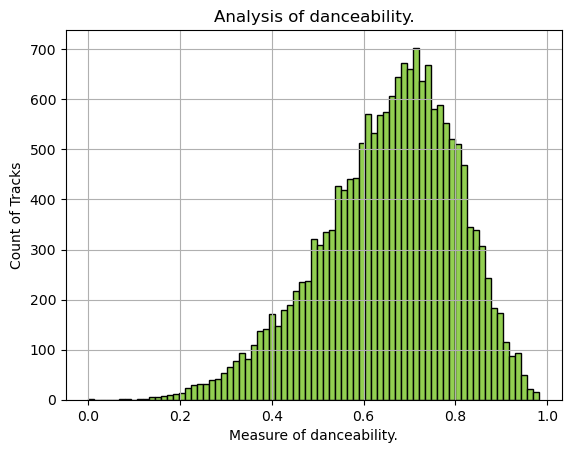

In [21]:
#Danceability mirrors energy of songs very closely keeping to a normal distribution with a slight left skew.

create_hist()

In [23]:
# Create a copy of the dataframe that's clearly labeled.

attr_report =  pd.DataFrame(df, columns=['track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 
                                          'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id',
                                          'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 
                                          'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'])

In [24]:
# Subset it to include only records from useful years, might adjust later so I'll make this a function
# Enter the year that is the bottom of the range it'll bump out a dataframe that is a subset of the main df.
def attr_report_years(year):
    attr_report =  pd.DataFrame(df, columns=['track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 
                                          'track_album_release_date', 'album_year', 'playlist_name', 'songs_on_playlist', 'playlist_id',
                                          'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 
                                          'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'])
    if type(year)==int or type(year)==float:
        attr_report = attr_report[attr_report['album_year']>year]
    
    # If the above conditions aren't met, send this. 
    else:
        print("Non-numeric value supplied to the input.")
        
    return attr_report
    

In [25]:
 # Enter the year that is the bottom of the range.
    
attr_report = attr_report_years(1980)

In [26]:
# This returns a pivot of whatever variable in the set categorized by the sub-category and the years specified in the attr_report

def create_report_gen():
   
    var = input('Enter column name to analyze.')
    
    if var not in attr_report.columns:
            print(f"Error: {var} not found in avilable DataFrame columns.")
            return None
# Check if the 'Title' column exists in the DataFrame
    if type(var)==str:

        report = pd.pivot_table(attr_report, values=var, index=['album_year'],
                       columns=['playlist_genre'], aggfunc="mean")
        
    else:
        print(f"Error: {var} does not contain str data.")
        
    return report

#album_year

In [27]:
# This returns a pivot of whatever variable in the set categorized by the sub-category and the years specified in the attr_report

def create_report():
   
    var = input('Enter column name to analyze.')
    
    if var not in attr_report.columns:
            print(f"Error: {var} not found in avilable DataFrame columns.")
            return None
# Check if the 'Title' column exists in the DataFrame
    if type(var)==str:

        report = pd.pivot_table(attr_report, values=var, index=['album_year'],
                       columns=['playlist_subgenre'], aggfunc="mean")
        
    else:
        print(f"Error: {var} does not contain str data.")
        
    return report

#album_year

In [28]:
genre_plot = create_report()

Enter column name to analyze. danceability


In [ ]:
## Export a csv file of a report made to the current working directory. 

def export_csv(data_frame):
    file_name = input('Enter the file save name: ')
    file_path = f"{file_name}.csv"
    file_directory = os.getcwd()

    # Check if the file already exists while giving the option to overwrite. 
    if os.path.exists(file_path):
        overwrite = input(f"The file '{file_path}' already exists. Do you want to overwrite it? (yes/no): ").lower()
        if overwrite != 'yes':
            print("Operation aborted. Choose a different filename.")
            return
   
    #Try catch language for a failed directory.
    try:
        data_frame.to_csv(file_path, index=False)
        print(f"CSV file '{file_path}' has been successfully written to the directory '{file_directory}'.")
    except Exception as e:
        print(f"Error: {e}. Failed to write the CSV file.")

In [29]:
genre_plot

playlist_subgenre,album rock,big room,classic rock,dance pop,electro house,electropop,gangster rap,hard rock,hip hop,hip pop,...,new jack swing,permanent wave,pop edm,post-teen pop,progressive electro house,reggaeton,southern hip hop,trap,tropical,urban contemporary
album_year,,,,,,,,,,,,,,,,,,,,,
1981,0.329000,NaN,0.548385,NaN,NaN,0.679250,NaN,0.480500,NaN,NaN,...,NaN,0.608833,NaN,NaN,0.734000,NaN,0.730500,NaN,NaN,0.706000
1982,0.625667,NaN,0.751667,NaN,NaN,0.784000,NaN,0.609000,NaN,NaN,...,0.733000,0.584600,NaN,0.533000,NaN,NaN,0.947000,NaN,NaN,0.842500
1983,0.638000,NaN,0.557500,NaN,NaN,0.680000,NaN,0.337000,NaN,NaN,...,NaN,0.592538,NaN,NaN,NaN,NaN,0.773000,NaN,NaN,NaN
1984,0.648312,NaN,NaN,NaN,NaN,0.721500,NaN,0.497000,NaN,0.664000,...,0.719000,0.608571,NaN,0.694000,NaN,NaN,0.919000,NaN,NaN,0.470000
1985,0.602600,NaN,0.508000,NaN,NaN,0.561333,NaN,0.411000,NaN,NaN,...,0.547500,0.548200,NaN,NaN,NaN,NaN,0.797000,NaN,NaN,NaN
1986,0.654625,NaN,NaN,NaN,NaN,0.744000,NaN,0.710000,NaN,NaN,...,0.701400,0.606800,NaN,NaN,NaN,NaN,0.791000,NaN,NaN,NaN
1987,0.496154,NaN,0.592600,NaN,NaN,0.715714,NaN,0.390000,NaN,NaN,...,0.781167,0.578636,NaN,NaN,NaN,NaN,0.615667,NaN,NaN,0.592500
1988,0.578857,NaN,0.392667,NaN,NaN,0.754000,0.881000,0.541909,NaN,NaN,...,0.747870,0.603400,NaN,NaN,NaN,NaN,0.759000,NaN,NaN,0.420000
1989,0.411000,NaN,0.518667,NaN,NaN,0.712200,NaN,0.539333,NaN,NaN,...,0.696000,0.549000,NaN,NaN,NaN,NaN,0.824000,NaN,NaN,NaN


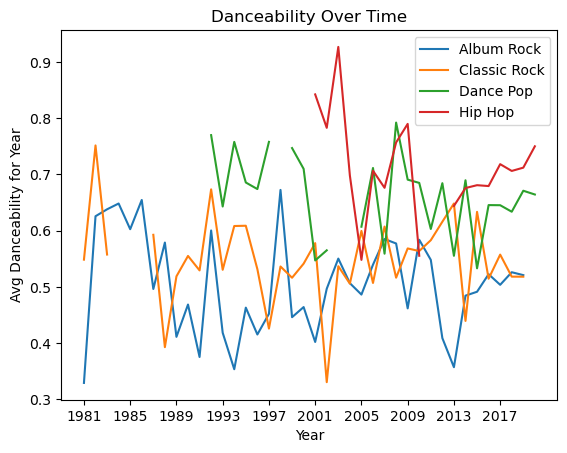

In [30]:
#Plot of danceability over time since 1980, shows that Rock genres are becoming less danceble in deference to pop and Hip Hop. 


# Plotting the lines
plt.plot(genre_plot.index, genre_plot['album rock'], label='Album Rock')
plt.plot(genre_plot.index, genre_plot['classic rock'], label='Classic Rock')
plt.plot(genre_plot.index, genre_plot['dance pop'], label='Dance Pop')
plt.plot(genre_plot.index, genre_plot['hip hop'], label='Hip Hop')

# Adding a legend
plt.legend()

# Adding labels and a title
plt.xlabel('Year')
plt.ylabel('Avg Danceability for Year')
plt.title('Danceability Over Time')
#Adjust the x axis labels
plt.xticks(genre_plot.index[::4])

# Display the plot
plt.show()